# Local Interpretation Methods : In-class Exercise 08-1

## Goal

Apply what you have learned about local interpretation methods to real data.

## Prerequisites

We need the following libraries:

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Data

### Wine

The data set contains quality ratings (assessed by blind tasting, on a scale from 0 to 10) for roughly 6500 red and white wines, along with given physiochemical properties.
The dataset is available as a CSV file:

In [2]:
wine = pd.read_csv("wine.csv")
wine = wine.dropna()

wine['type'] = wine['type'].astype('category')

wine = pd.get_dummies(wine, columns=["type"])

features = [col for col in wine.columns if col != "quality"]
X = wine[features]
y = wine["quality"]

## Fit a Random Forest

We fit a random forest to predict the quality and use a train-test split, reserving 500 observations for testing:

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=500, random_state=124
)

forest = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=124)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Mean Squared Error: {mse:.6f}")
print(f"Test R^2 Score: {r2:.2%}")

Test Mean Squared Error: 0.417163
Test R^2 Score: 49.60%


## Exercise 1 & 2: LIME

LIME (Local Interpretable Model-Agnostic Explanations) is a technique used to explain individual predictions of any machine learning model by approximating it locally with an interpretable model. This simplification helps identify which features contribute most to a specific prediction, providing valuable insights into model behavior.
In this exercise, we will create a LIME explainer to explain the random forest prediction for the first observation in the test data by fitting a local linear regression model. The explanation will show which features most influence the predicted wine quality for this specific instance.

### Task
You will:
* Use the `lime` library to create a LIME explainer.
* Explain the prediction for the first observation in the test set.
* Display the explanation both as a printed list of feature contributions and as a plot.

<details><summary>Hint 1:</summary> 
You need to use `lime.lime_tabular.LimeTabularExplainer`.
</details>

<details><summary>Hint 2:</summary> 
You need to provide LIME with a prediction function that takes a 2D NumPy array and returns the corresponding predictions. You also need to convert the `X_test` observation to a NumPy array using `.values`. 
</details>


LIME explanation for instance 0:
Predicted quality: 5.29

Feature contributions:
alcohol <= 9.50: -0.4508
volatile acidity > 0.40: -0.3871
29.00 < free sulfur dioxide <= 41.00: 0.1111


<Figure size 1000x600 with 0 Axes>

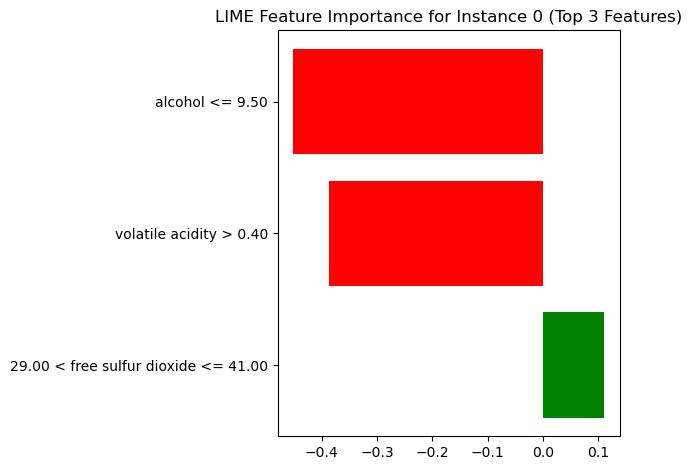

In [4]:
#===SOLUTION===

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Select a test instance to explain
instance_idx = 0
instance = X_test.iloc[instance_idx].values  
instance_prediction = forest.predict(X_test.iloc[[instance_idx]])[0]

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, 
    feature_names=features,
    class_names=['quality'],
    mode='regression',
    random_state=42
)

# Get the explanation
# Create a wrapper function to ensure feature names are preserved
def predict_fn(x):
    x_df = pd.DataFrame(x, columns=features)
    return forest.predict(x_df)

exp = explainer.explain_instance(
    instance, 
    predict_fn,
    num_features=3
)

print(f"\nLIME explanation for instance {instance_idx}:")
print(f"Predicted quality: {instance_prediction:.2f}")
print("\nFeature contributions:")
for feature, importance in exp.as_list():
    print(f"{feature}: {importance:.4f}")

plt.figure(figsize=(10, 6))
exp.as_pyplot_figure()
plt.title(f'LIME Feature Importance for Instance {instance_idx} (Top 3 Features)')
plt.tight_layout()
plt.show()


## Data

### Wine

The data set contains quality ratings (assessed by blind tasting, on a scale from 0 to 10) for roughly 6500 red and white wines, along with given physiochemical properties.
The dataset is available as a CSV file:

### Exercise 3: ICE

Individual Conditional Expectation (ICE) plots display one line per instance showing how the instance’s prediction changes when a specific feature varies. Unlike Partial Dependence Plots (PDP), which average over all instances, ICE plots visualize the dependence of predictions on a feature for each instance separately, resulting in one line per instance. This provides a more detailed view of individual effects and possible heterogeneity across instances.

Your task is to create an ICE plot for the feature alcohol and describe the feature-target relationship you observe.

### Task
You will:
* Compute an ICE plot for the feature alcohol by varying it systematically.
* Plot the individual curves for several instances.
* Overlay the PDP (average curve) on the same plot.

Interpret the relationship between alcohol and the predicted quality.

Note: In Python, the most convenient way to create ICE plots is using `sklearn.inspection.PartialDependenceDisplay`.
However, at the time of creation of this exercise, we encountered a compatibility issue between `scikit-learn 1.6.1` and `numpy 2.0`, preventing direct use of `PartialDependenceDisplay`. Therefore, we will provide a manual implementation of the ICE plot from scratch in the solution.

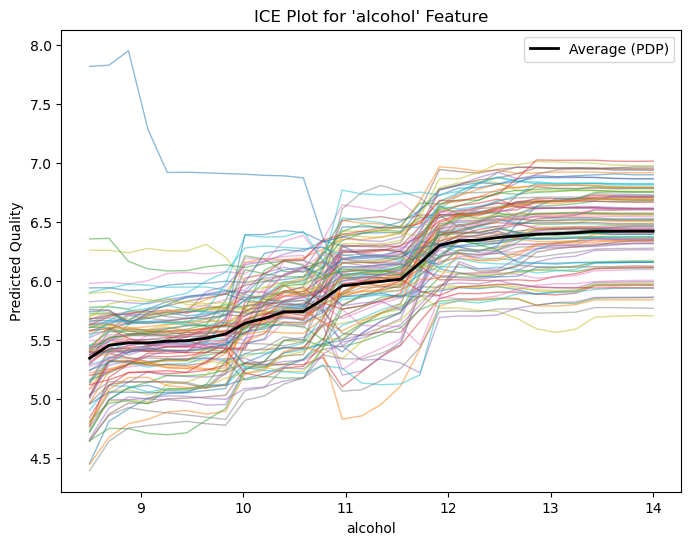

In [5]:
#===SOLUTION===

# Let's implement our own ICE plot since there's an compatibility issue between sklearn.inspection and numpy >=2.0
# We'll manually calculate the ICE values for the 'alcohol' feature

# Create a range of values for the 'alcohol' feature
alcohol_values = np.linspace(X_test['alcohol'].min(), X_test['alcohol'].max(), 30)

n_samples = 100
sample_indices = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
X_samples = X_test.iloc[sample_indices]

fig, ax = plt.subplots(figsize=(8, 6))

for i, idx in enumerate(sample_indices):
    ice_predictions = []
    sample = X_test.iloc[idx].copy()
    
    # Create modified versions of the sample with different alcohol values
    for val in alcohol_values:
        modified_sample = sample.copy()
        modified_sample['alcohol'] = val
        pred = forest.predict(pd.DataFrame([modified_sample]))[0]
        ice_predictions.append(pred)
    
    ax.plot(alcohol_values, ice_predictions, alpha=0.5, linewidth=1)

# Calculate and plot the average effect (PDP)
pdp_values = []
for val in alcohol_values:
    X_modified = X_test.copy()
    X_modified['alcohol'] = val
    predictions = forest.predict(X_modified)
    pdp_values.append(predictions.mean())

ax.plot(alcohol_values, pdp_values, color='black', linewidth=2, label='Average (PDP)')

ax.set_xlabel('alcohol')
ax.set_ylabel('Predicted Quality')
ax.set_title("ICE Plot for 'alcohol' Feature")
ax.legend()
plt.show()


Question: what conclusion can you make?

===SOLUTION===

For most (but not all) observations, alcohol seems to positively influence predicted quality.

## Exercise 4: Counterfactual Explanations

We do not provide a Python solution for this exercise yet, as current off-the-shelf packages for counterfactual explanations are outdated and incompatible with recent versions of scikit-learn. We will include a solution in the future, either if a suitable package becomes available or if we develop a proper implementation from scratch. 

@matthias, I also tried to implement from scratch but could not make the output aligned with the R solution. Therefore, I am inclined to skip this exercise for now.

## Summary

We learned how to implement interpretation methods for LIME, ICE.